# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.


---


> Para comenzar a explorar los datos, haré lo siguiente:
* Primero, voy a importar las bibliotecas que necesito. Usaré pandas para manejar y analizar los datos.
* Luego, voy a leer los cinco archivos CSV: instacart_orders.csv, products.csv, aisles.csv, departments.csv y order_products.csv. Los cargaré en DataFrames de pandas. Usaré el parámetro sep=';' porque los archivos usan punto y coma como separador.
* Después, revisaré la información de cada DataFrame con el método .info(). Esto me ayudará a ver cuántas filas y columnas hay, qué tipo de datos tiene cada columna y cuántos valores faltan. Así podré saber si hay datos ausentes desde el inicio.

In [1]:
# importar librerías
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
# leer conjuntos de datos en los DataFrames
'''
aisles = pd.read_csv('/datasets/aisles.csv')
departments = pd.read_csv('/datasets/departments.csv')
order_products = pd.read_csv('/datasets/order_products.csv')
orders = pd.read_csv('/datasets/instacart_orders.csv')
products = pd.read_csv('/datasets/products.csv')
'''

aisles = pd.read_csv('/content/aisles.csv', sep=';')
departments = pd.read_csv('/content/departments.csv', sep=';')
order_products = pd.read_csv('/content/order_products.csv', sep=';')
orders = pd.read_csv('/content/instacart_orders.csv', sep=';')
products = pd.read_csv('/content/products.csv', sep=';')

In [3]:
# mostrar información del DataFrame AISLES
aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [4]:
# mostrar información del DataFrame DEPARTMENTS
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


In [5]:
# mostrar información del DataFrame INSTACART ORDERS
order_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [6]:
# mostrar información del DataFrame
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [7]:
# mostrar información del DataFrame
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.


---

> Usé el método .info() para revisar cada uno, y esto fue lo que encontré:
* Los DataFrames *aisles* y *departments* son tablas pequeñas que sirven como referencia. Están completos, no tienen valores faltantes y los tipos de datos son correctos. Las columnas de ID son números enteros y las de nombres son texto.
* El DataFrame *orders* tiene 478,967 filas. La columna **days_since_prior_order** tiene muchos valores faltantes: 28,819 en total, ya que solo hay 450,148 valores completos. Esta columna es de tipo float64, seguramente porque los valores faltantes se marcan como NaN.
* En el DataFrame *products*, la columna **product_name** tiene 1,258 valores faltantes. De un total de 49,694 registros, solo 48,436 tienen datos en esa columna.
* El DataFrame *order_products* es el que más memoria usa. La columna **add_to_cart_order** aparece como float64, lo cual es raro, porque debería ser un número entero que muestra el orden en que se agregaron los productos al carrito. Esto puede indicar que también hay valores faltantes.

# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.


---

> Para preparar los datos, voy a revisar cada DataFrame y corregir cualquier problema. Este es el plan que seguiré:
  1. Buscar y eliminar duplicados.
    * En el DataFrame orders, voy a revisar si hay pedidos exactamente iguales. Si los encuentro, los eliminaré para no contar dos veces lo mismo. También voy a mirar bien esas filas duplicadas para entender por qué están repetidas.
    * En los DataFrames products, departments, aisles y order_products también buscaré duplicados. En products, pondré especial atención a los nombres repetidos. Para compararlos mejor, los pasaré a mayúsculas y así ver si son realmente iguales.
2. Identificar y completar valores faltantes:
    * En el DataFrame products, revisaré por qué faltan valores en la columna product_name. Veré si esos productos están ligados a un pasillo o departamento en particular. Si es así, les pondré un nombre genérico como “Unknown”.
    * En orders, miraré los valores que faltan en days_since_prior_order. Creo que estos se deben a que son el primer pedido de cada usuario (cuando order_number es 1). Si eso se confirma, los dejaré como están, ya que tiene sentido que no haya un valor previo.
    * En order_products, si hay valores faltantes en add_to_cart_order, los reemplazaré con un número fuera de lo normal, como 999. Esto me ayudará a identificarlos fácilmente más adelante.
3. Corregir tipos de datos:
    * Una vez que haya tratado los valores faltantes, revisaré los tipos de datos. En especial, voy a cambiar la columna add_to_cart_order de float64 a int64, porque debería ser un número entero.

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [8]:
# Revisa si hay pedidos duplicados
print(orders.duplicated().sum())

print(orders[orders.duplicated()])

15
        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48         

¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

> Sí, encontré 15 filas duplicadas en el DataFrame. Todas tienen algo en común: los pedidos se hicieron el mismo día y a la misma hora. Ocurrieron un miércoles (día 3) a las 2:00 de la mañana.

In [9]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
print(orders.duplicated())
print(orders[(orders['order_dow'] == 3) & (orders['order_hour_of_day'] == 2)])

0         False
1         False
2         False
3         False
4         False
          ...  
478962    False
478963    False
478964    False
478965    False
478966    False
Length: 478967, dtype: bool
        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                

¿Qué sugiere este resultado?

> Este patrón tan específico me hace pensar que los duplicados no se deben a un error al escribir los datos, sino a un problema técnico o un fallo en el sistema. Es posible que un grupo de pedidos procesados a esa hora se haya guardado más de una vez.

In [10]:
# Elimina los pedidos duplicados
orders = orders.drop_duplicates()

In [11]:
# Vuelve a verificar si hay filas duplicadas
print(orders.duplicated().sum())

0


In [12]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
print(orders['order_id'].unique())
print(orders['order_id'].duplicated().sum())

[1515936 1690866 1454967 ...  885349  216274 2071924]
0


Describe brevemente tus hallazgos y lo que hiciste con ellos

> Encontré 15 filas que eran exactamente iguales. Como parecía que se debían a un error técnico y podían afectar el análisis, decidí eliminarlas con el método .drop_duplicates(). Después, revisé otra vez y confirmé que ya no había filas duplicadas en el DataFrame.

### `products` data frame

In [13]:
# Verifica si hay filas totalmente duplicadas
print(products.duplicated().sum())

0


In [14]:
# Revisa únicamente si hay ID de productos duplicados
print(products['product_id'].unique())
print(products['product_id'].duplicated().sum())

[    1     2     3 ... 49692 49693 49694]
0


In [15]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
products['product_name'] = products['product_name'].str.upper()
print(products['product_name'].unique())
print(products['product_name'].duplicated().sum())

['CHOCOLATE SANDWICH COOKIES' 'ALL-SEASONS SALT'
 'ROBUST GOLDEN UNSWEETENED OOLONG TEA' ... 'ARTISAN BAGUETTE'
 'SMARTBLEND HEALTHY METABOLISM DRY CAT FOOD' 'FRESH FOAMING CLEANSER']
1361


In [16]:
# Revisa si hay nombres duplicados de productos no faltantes
print(products['product_name'].isna().sum())

1258


Describe brevemente tus hallazgos y lo que hiciste con ellos.

> No encontré filas totalmente iguales ni product_id repetidos. Pero cuando pasé los nombres de producto a mayúsculas, descubrí que hay 1,361 nombres que están duplicados.
Por ahora no eliminé ninguna fila, pero hacer esta estandarización fue un paso importante para limpiar los datos. Que haya nombres repetidos puede significar que hay productos diferentes con el mismo nombre.

### `departments` data frame

In [17]:
# Revisa si hay filas totalmente duplicadas
print(departments.duplicated().sum())

0


In [18]:
# Revisa únicamente si hay IDs duplicadas de departamentos
print(departments['department_id'].unique())
print(departments['department_id'].duplicated().sum())

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

> Revisé si había filas exactamente iguales o department_id repetidos, pero no encontré ningún problema. El DataFrame departments está limpio y no tuve que hacer ningún cambio.

### `aisles` data frame

In [19]:
# Revisa si hay filas totalmente duplicadas
print(aisles.duplicated().sum())

0


In [20]:
# Revisa únicamente si hay IDs duplicadas de pasillos
print(aisles['aisle_id'].unique())
print(aisles['aisle_id'].duplicated().sum())

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134]
0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

> Como con los departamentos, revisé si había filas duplicadas o aisle_id repetidos. Verifiqué y no encontré duplicados en este DataFrame. Por eso, no tuve que hacer ninguna limpieza.

### `order_products` data frame

In [21]:
# Revisa si hay filas totalmente duplicadas
print(order_products.duplicated().sum())

0


In [22]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
for col in order_products.columns:
    print(order_products[col].unique())

[2141543  567889 2261212 ...  812418 2666881 1461911]
[11440  1560 26683 ... 49153  8182 40024]
[17.  1. 35.  5.  4. 10. 14.  2. 28.  3. 16.  8.  7.  6.  9. 15. 22. 49.
 19. 13. 11. 12. 18. 24. 23. 45. 30. 31. 29. 21. 38. 20. 57. 58. 26. 25.
 39. 34. 40. 27. nan 43. 33. 42. 50. 32. 36. 37. 61. 46. 56. 41. 44. 55.
 54. 47. 63. 48. 60. 62. 53. 59. 52. 51. 64.]
[0 1]


Describe brevemente tus hallazgos y lo que hiciste con ellos.

> Revisé el DataFrame para ver si había filas completamente duplicadas, pero no encontré ninguna. Esto quiere decir que no hay registros iguales y repetidos de un producto en un mismo pedido. El conjunto de datos está consistente en ese sentido, así que no eliminé ninguna fila.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [23]:
# Encuentra los valores ausentes en la columna 'product_name'
print(products['product_name'].isna().sum())

1258


Describe brevemente cuáles son tus hallazgos.

> La salida muestra que hay un total de 1,258 valores ausentes en la columna product_name.

In [24]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
print(products[products['product_name'].isna()])
print(products[(products['aisle_id'] == 100) & (products['product_name'].isna())])

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]
       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417      

Describe brevemente cuáles son tus hallazgos.

> Al analizar los datos, vi un patrón claro: los 1,258 productos que no tienen nombre pertenecen al mismo pasillo (aisle_id 100). Esto me indica que el problema no es al azar, sino que está relacionado directamente con ese pasillo.

In [25]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
print(products[(products['department_id'] == 21) & (products['product_name'].isna())])

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


Describe brevemente cuáles son tus hallazgos.

> De la misma forma, confirmé que los 1,258 productos sin nombre también pertenecen al mismo departamento (department_id 21).

In [26]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
print(departments[departments['department_id'] == 21])
print(aisles[aisles['aisle_id'] == 100])

    department_id department
20             21    missing
    aisle_id    aisle
99       100  missing


Describe brevemente cuáles son tus hallazgos.

> Al revisar las tablas de referencia, vi que tanto el aisle_id 100 como el department_id 21 están etiquetados como "missing" (ausente). Esto me confirma que los nombres de producto no se perdieron por error, sino que vienen de categorías que ya estaban marcadas como desconocidas en la base de datos.

In [27]:
# Completa los nombres de productos ausentes con 'Unknown'
products['product_name'] = products['product_name'].fillna('Unknown')

print(products.isna().sum())

product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64


Describe brevemente tus hallazgos y lo que hiciste con ellos.

> Como todos los nombres ausentes estaban en un pasillo y departamento marcados como "missing", llené esos valores con la palabra "Unknown". Luego revisé la tabla otra vez y confirmé que ya no hay valores nulos en la columna product_name.

### `orders` data frame

In [28]:
# Encuentra los valores ausentes
print(orders.isna().sum())

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64


In [29]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
print(orders[orders['days_since_prior_order'].isna()])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478895   2589657   205028             1          0                 16   
478896   2222353   141211             1          2                 13   
478922   2272807   204154             1          1                 15   
478926   2499542    68810             1          4                 19   
478945   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100                     

Describe brevemente tus hallazgos y lo que hiciste con ellos.

> Encontré 28,817 valores faltantes en la columna days_since_prior_order.

> Al revisar, descubrí que todos esos casos corresponden a pedidos con order_number igual a 1. Esto tiene sentido, porque se trata del primer pedido de cada cliente, así que no puede haber un “tiempo desde el pedido anterior”.

> Como no es un error, sino parte natural de los datos, decidí no hacer ningún cambio y dejar esos valores tal como están.

### `order_products` data frame

In [30]:
# Encuentra los valores ausentes
print(order_products.isna().sum())

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


In [31]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print(order_products['add_to_cart_order'].min())
print(order_products['add_to_cart_order'].max())

1.0
64.0


Describe brevemente cuáles son tus hallazgos.

> Al analizar la columna add_to_cart_order, vi que el valor mínimo es 1.0 y el máximo es 64.0. Esto me indica que, en los pedidos con datos completos, los clientes agregan entre 1 y 64 productos a su carrito.

In [32]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
ids_missing_add_to_cart = order_products[order_products['add_to_cart_order'].isna()]['order_id']

In [33]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
print(order_products[order_products['add_to_cart_order'].isna()])
print(order_products['product_id'].groupby(order_products['order_id']).count().min())

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]
1


Describe brevemente cuáles son tus hallazgos.

> Hay 836 filas con valores faltantes en la columna add_to_cart_order. Al revisar más a fondo, vi que el número mínimo de productos en cualquier pedido es 1. No encontré evidencia de que los pedidos con valores ausentes tengan más de 64 productos, así que no parece que sean pedidos especialmente grandes.

In [34]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999)
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype(int)

print(order_products.isna().sum())

print(order_products.info())

order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 138.7 MB
None


Describe brevemente tus hallazgos y lo que hiciste con ellos.

> Para manejar los 836 valores faltantes, los reemplacé con el número 999. Elegí ese valor porque está muy fuera del rango normal (que va de 1 a 64), así puedo identificar fácilmente esas entradas. Después, cambié el tipo de la columna add_to_cart_order de float a int, ya que debe contener solo números enteros. Al final, usé .info() y confirmé que la columna ahora es de tipo int64 y ya no tiene valores nulos.

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos

> Durante el preprocesamiento, traté los valores duplicados y faltantes, dejando los datos listos para el análisis. Estas fueron las acciones principales:

> ### Manejo de duplicados:
  * Encontré y eliminé 15 filas duplicadas en el DataFrame orders. Estas filas parecían repetirse por un error técnico.
  * Los DataFrames aisles, departments y order_products no tenían filas duplicadas.
  * En la tabla products, no había filas completas repetidas, pero sí detecté 1,361 nombres de producto duplicados. Esto puede indicar errores o nombres iguales para productos diferentes.

> ### Manejo de valores ausentes:
  * En la columna days_since_prior_order (tabla orders), los valores faltantes correspondían al primer pedido de cada cliente, así que los dejé sin modificar.
  * Los 1,258 productos sin nombre en la tabla products estaban todos en un pasillo y departamento marcados como "missing". Reemplacé esos valores con la palabra "Unknown" para mantener la coherencia.
  * Los 836 valores faltantes en add_to_cart_order (tabla order_products) los rellené con el número 999, como marcador.

> ### Corrección de tipos de datos:
  * Después de completar los valores faltantes, cambié la columna add_to_cart_order de tipo float a int, ya que debe contener números enteros en orden secuencial.
  * Con estos cambios, los datos ahora están limpios, completos y listos para hacer el análisis exploratorio.

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [35]:
print(orders['order_hour_of_day'].min())
print(orders['order_hour_of_day'].max())

0
23


In [36]:
print(orders['order_dow'].min())
print(orders['order_dow'].max())

0
6


Escribe aquí tus conclusiones

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

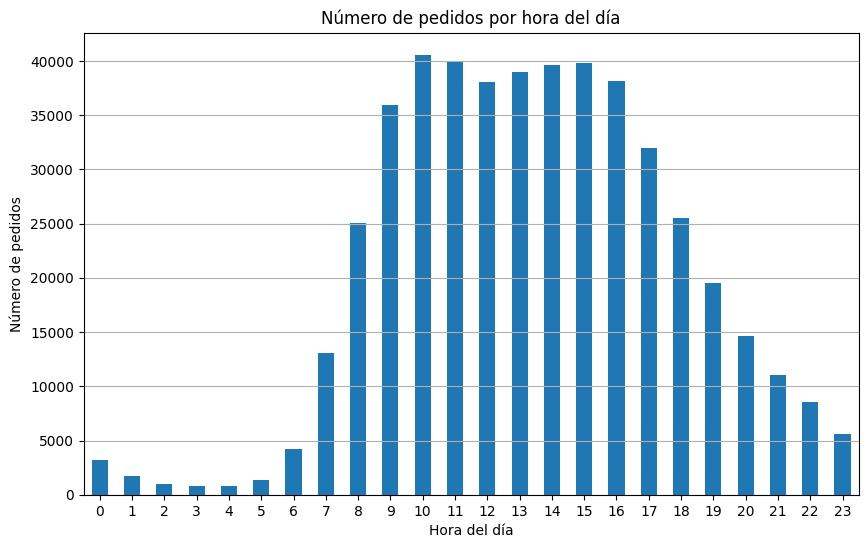

In [66]:
orders_by_hour = orders['order_hour_of_day'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
orders_by_hour.plot(kind='bar')
plt.xlabel('Hora del día')
plt.ylabel('Número de pedidos')
plt.title('Número de pedidos por hora del día')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

Escribe aquí tus conclusiones

### [A3] ¿Qué día de la semana compran víveres las personas?

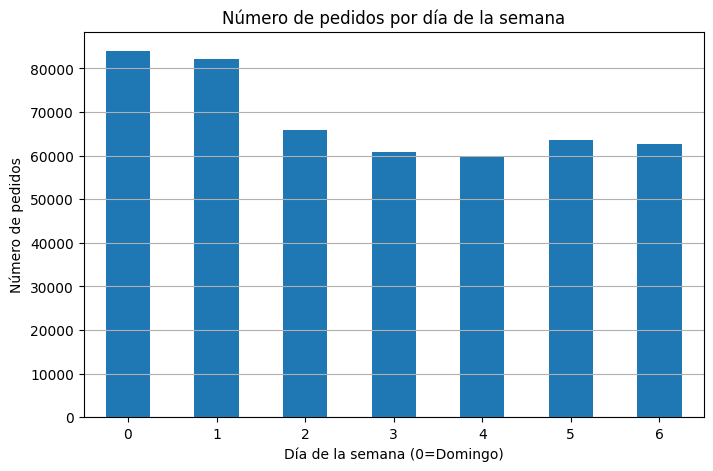

In [65]:
orders_by_weekday = orders['order_dow'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
orders_by_weekday.plot(kind='bar')
plt.xlabel('Día de la semana (0=Domingo)')
plt.ylabel('Número de pedidos')
plt.title('Número de pedidos por día de la semana')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

Escribe aquí tus conclusiones

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

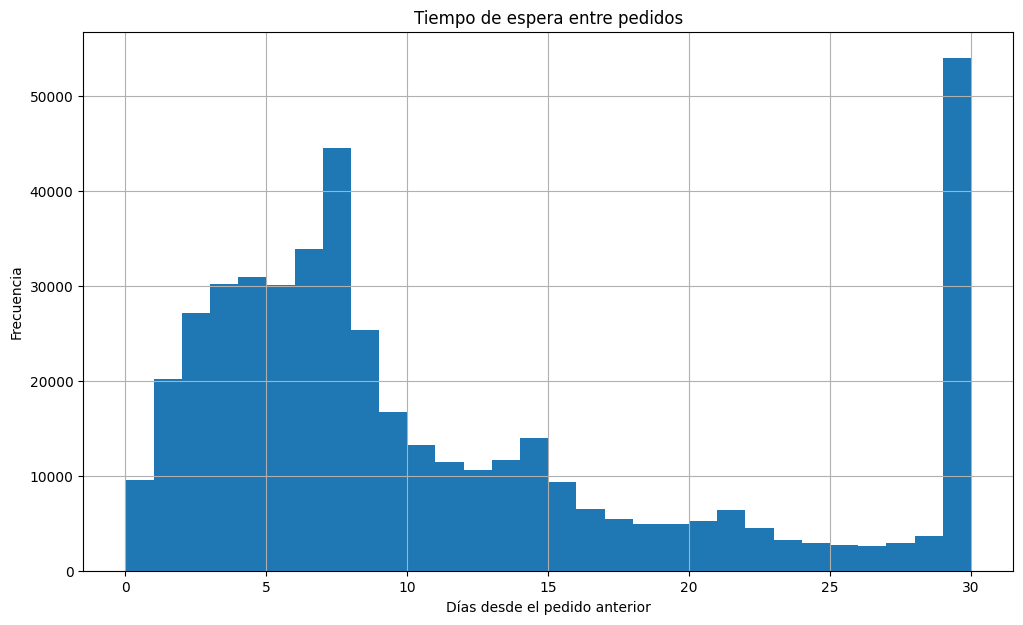

Valor mínimo de espera entre pedidos: 0.0
Valor máximo de espera entre pedidos: 30.0


In [64]:
plt.figure(figsize=(12, 7))
prior_order_waiting_time = orders['days_since_prior_order'].hist(bins=30)
plt.xlabel('Días desde el pedido anterior')
plt.ylabel('Frecuencia')
plt.title('Tiempo de espera entre pedidos')
plt.show()

print("Valor mínimo de espera entre pedidos:", orders['days_since_prior_order'].min())
print("Valor máximo de espera entre pedidos:", orders['days_since_prior_order'].max())

Escribe aquí tus conclusiones

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

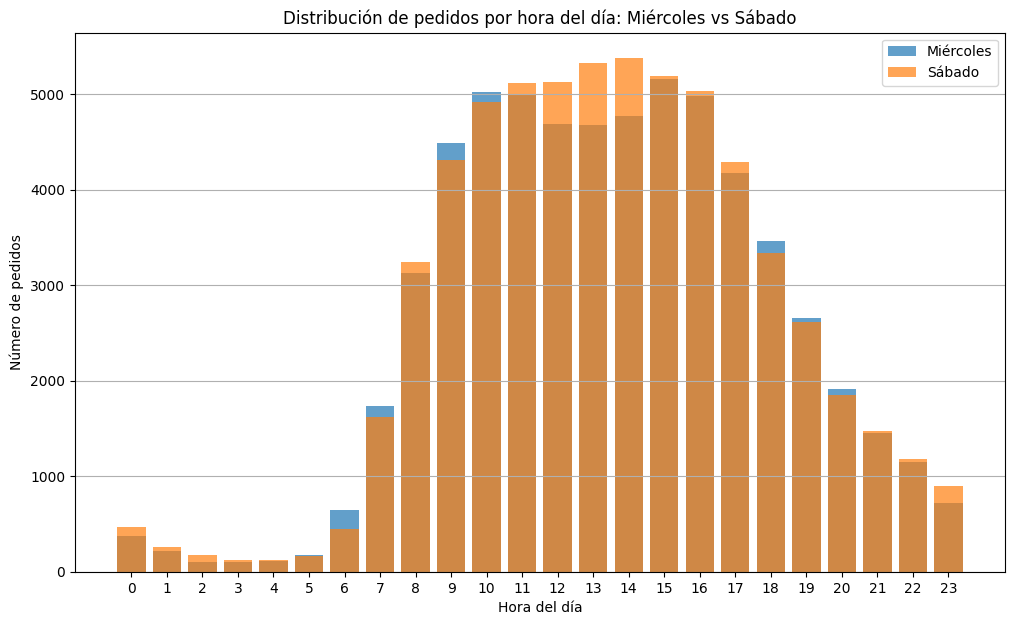

In [60]:
orders_wednesday = orders[orders['order_dow'] == 3]['order_hour_of_day'].value_counts().sort_index()
orders_saturday = orders[orders['order_dow'] == 6]['order_hour_of_day'].value_counts().sort_index()

plt.figure(figsize=(12, 7))
plt.bar(orders_wednesday.index, orders_wednesday.values, alpha=0.7, label='Miércoles')
plt.bar(orders_saturday.index, orders_saturday.values, alpha=0.7, label='Sábado')
plt.xlabel('Hora del día')
plt.ylabel('Número de pedidos')
plt.title('Distribución de pedidos por hora del día: Miércoles vs Sábado')
plt.xticks(range(24))
plt.legend()
plt.grid(axis='y')
plt.show()

Escribe aquí tus conclusiones

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

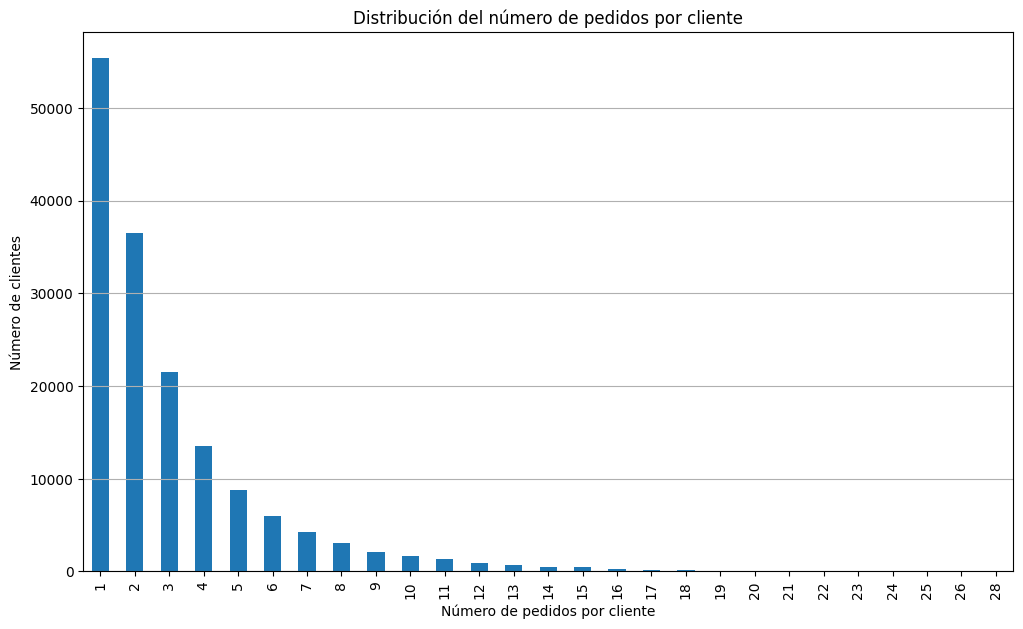

In [59]:
# Contar cuántos pedidos ha hecho cada cliente
order_count_by_customer = orders.groupby('user_id')['order_id'].count()

# Graficar la distribución del número de pedidos por cliente
plt.figure(figsize=(12, 7))
order_count_by_customer.value_counts().sort_index().plot(kind='bar')
plt.xlabel('Número de pedidos por cliente')
plt.ylabel('Número de clientes')
plt.title('Distribución del número de pedidos por cliente')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.show()

In [42]:
print(orders['user_id'].value_counts().min())
print(orders['user_id'].value_counts().max())

1
28


Escribe aquí tus conclusiones

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

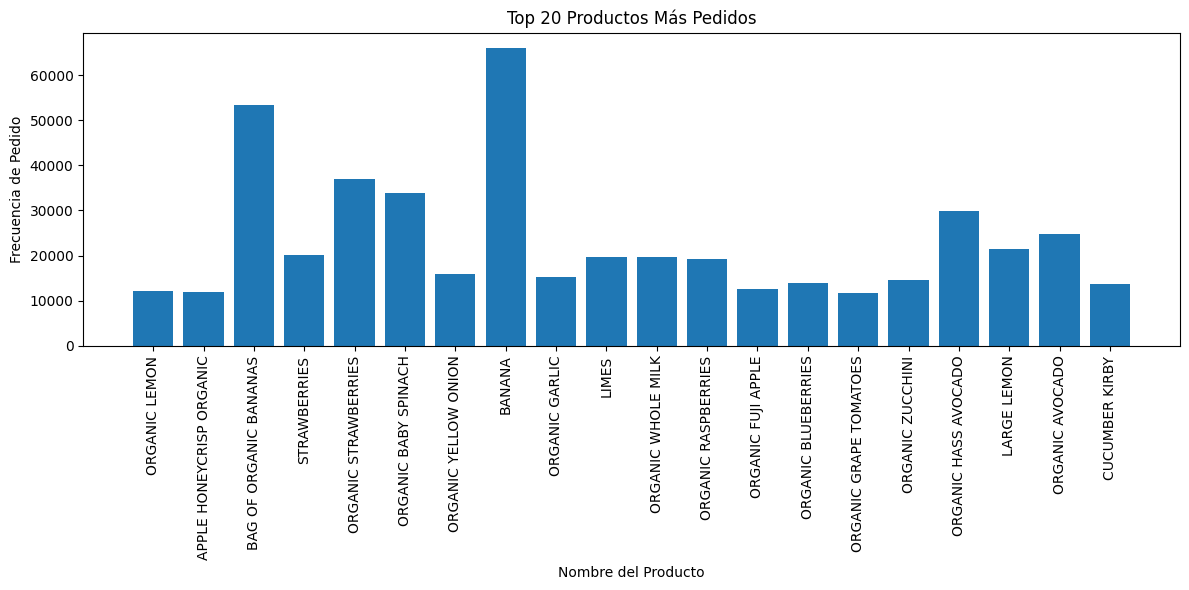

In [58]:
order_counts = order_products['product_id'].value_counts().head(20)
top_20_products = products[products['product_id'].isin(order_counts.index)]
merged_top_20 = top_20_products.merge(order_counts.rename('order_count'), left_on='product_id', right_index=True)

plt.figure(figsize=(12, 6))
plt.bar(merged_top_20['product_name'], merged_top_20['order_count'])
plt.xticks(rotation=90)
plt.xlabel('Nombre del Producto')
plt.ylabel('Frecuencia de Pedido')
plt.title('Top 20 Productos Más Pedidos')
plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

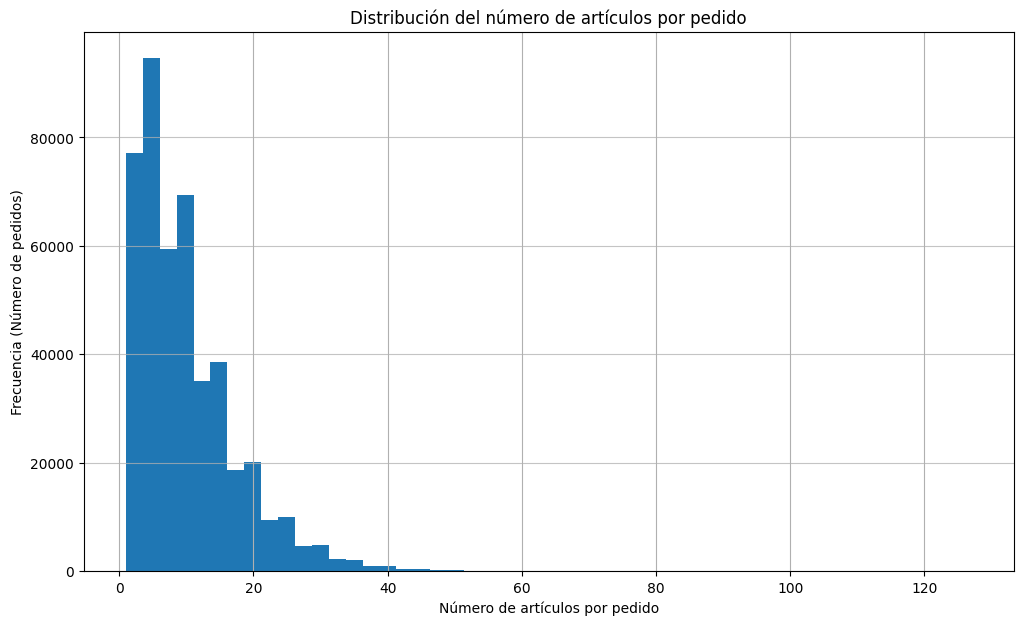

Estadísticas descriptivas para el número de artículos por pedido:
count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
Name: product_id, dtype: float64


In [57]:
# Agrupar por order_id y contar el número de productos en cada pedido
items_per_order = order_products.groupby('order_id')['product_id'].count()

# Graficar la distribución del número de artículos por pedido
plt.figure(figsize=(12, 7))
items_per_order.hist(bins=50) # Ajusta el número de bins según sea necesario para visualizar la distribución
plt.xlabel('Número de artículos por pedido')
plt.ylabel('Frecuencia (Número de pedidos)')
plt.title('Distribución del número de artículos por pedido')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("Estadísticas descriptivas para el número de artículos por pedido:")
print(items_per_order.describe())

Escribe aquí tus conclusiones

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

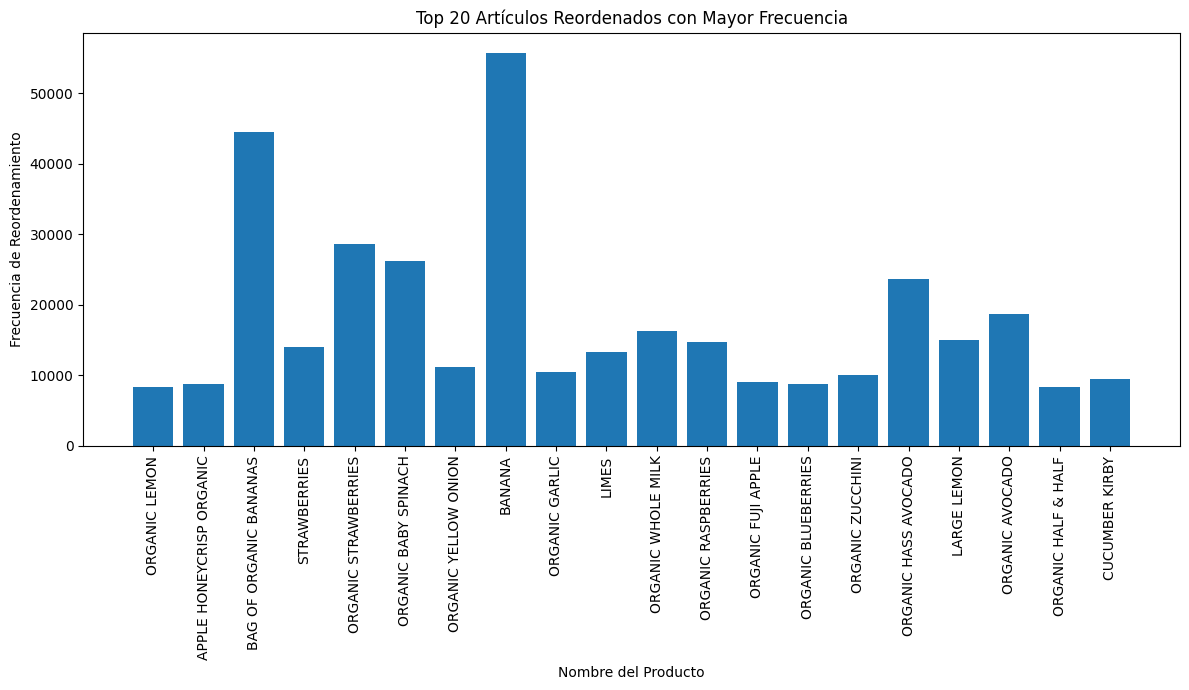

In [55]:
# Filtrar los productos que han sido reordenados
reordered_products = order_products[order_products['reordered'] == 1]

# Contar cuántas veces se ha reordenado cada producto
reorder_counts = reordered_products['product_id'].value_counts().head(20)

# Obtener los nombres de los productos y IDs correspondientes
top_20_reordered = products[products['product_id'].isin(reorder_counts.index)]

# Unir con el conteo de reordenamientos y ordenar
merged_top_20_reordered = top_20_reordered.merge(reorder_counts.rename('reorder_count'), left_on='product_id', right_index=True)

# Opcional: Graficar los 20 principales artículos reordenados
plt.figure(figsize=(12, 7))
plt.bar(merged_top_20_reordered['product_name'], merged_top_20_reordered['reorder_count'])
plt.xticks(rotation=90)
plt.xlabel('Nombre del Producto')
plt.ylabel('Frecuencia de Reordenamiento')
plt.title('Top 20 Artículos Reordenados con Mayor Frecuencia')
plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

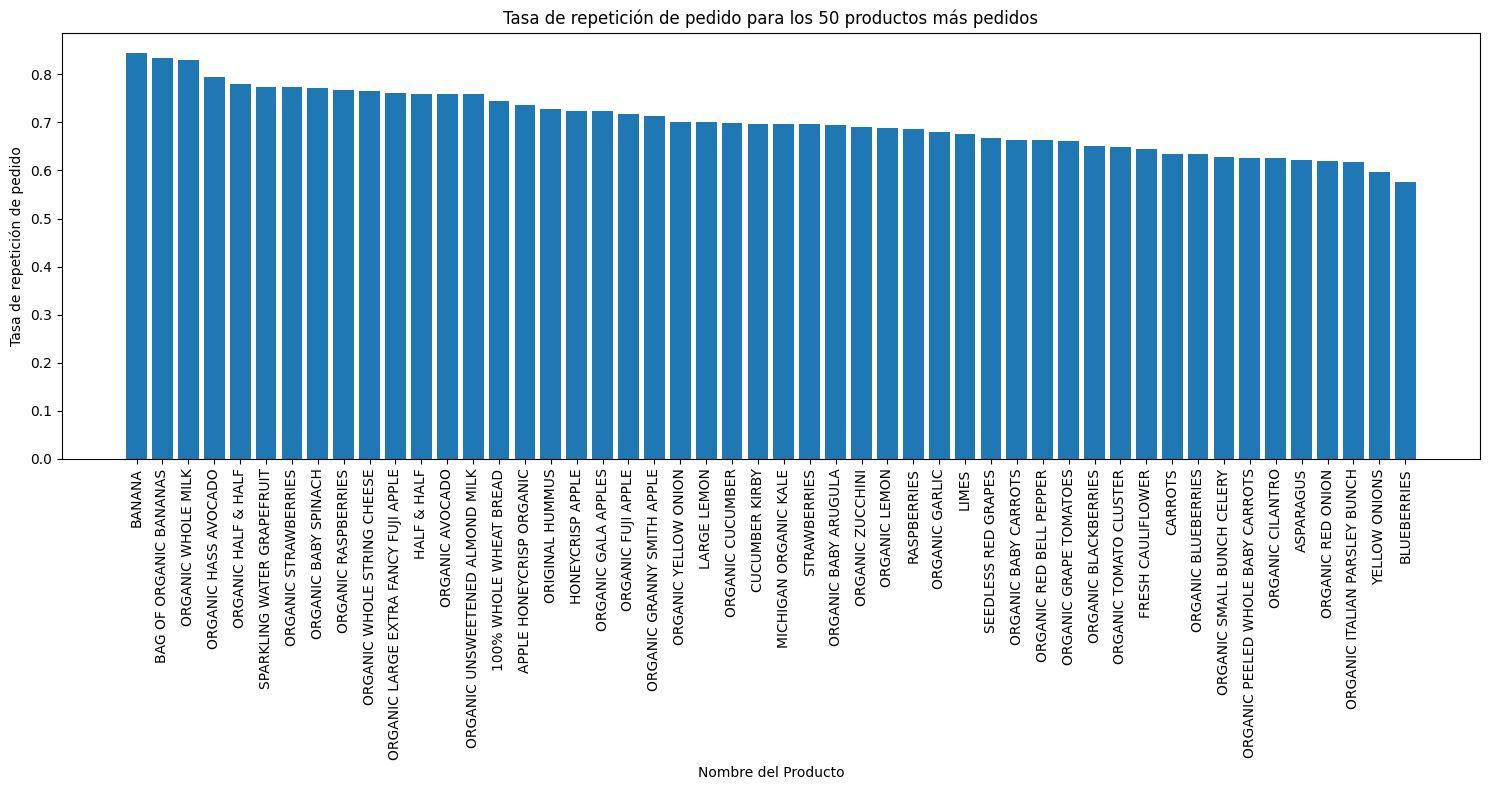

In [54]:
# Calcular el número total de pedidos para cada producto
total_orders_per_product = order_products.groupby('product_id')['order_id'].count()

# Calcular el número de reordenamientos para cada producto
reorders_per_product = order_products[order_products['reordered'] == 1].groupby('product_id')['order_id'].count()

# Calcular la tasa de repetición de pedido (reordenamientos / total de pedidos)
# Es importante manejar los productos que nunca se han pedido de nuevo (tasa de repetición = 0)
reorder_rate = (reorders_per_product / total_orders_per_product).fillna(0)

# Unir la tasa de repetición con los nombres de los productos
product_reorder_rate = products.merge(reorder_rate.rename('reorder_rate'), left_on='product_id', right_index=True)

# Para los 50 productos más pedidos:
top_50_most_ordered = order_products['product_id'].value_counts().head(50).index
top_50_reorder_rate = product_reorder_rate[product_reorder_rate['product_id'].isin(top_50_most_ordered)]

# Ordenar por tasa de repetición de pedido descendente
top_50_reorder_rate_sorted = top_50_reorder_rate.sort_values(by='reorder_rate', ascending=False)

# Graficar la tasa de repetición para los 50 productos más pedidos
plt.figure(figsize=(15, 8))
plt.bar(top_50_reorder_rate_sorted['product_name'], top_50_reorder_rate_sorted['reorder_rate'])
plt.xticks(rotation=90)
plt.xlabel('Nombre del Producto')
plt.ylabel('Tasa de repetición de pedido')
plt.title('Tasa de repetición de pedido para los 50 productos más pedidos')
plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

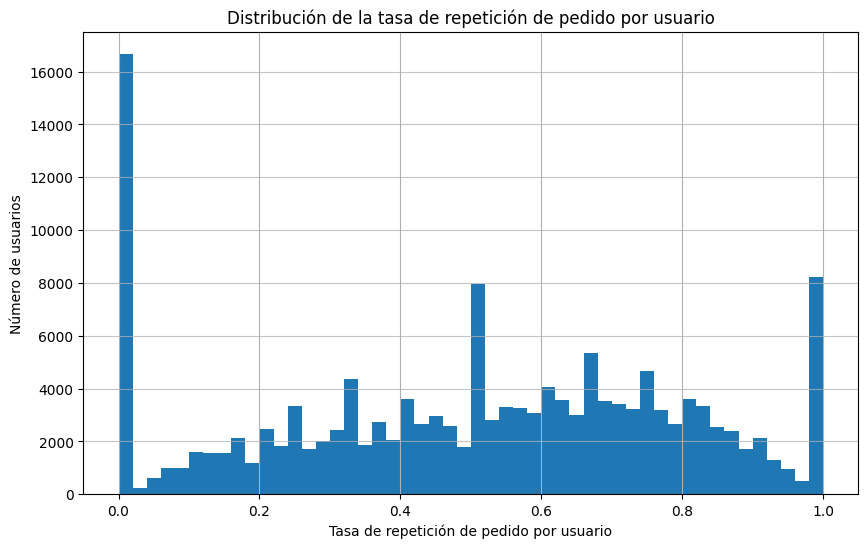


Estadísticas descriptivas para la tasa de repetición de pedido por usuario:
count    149626.000000
mean          0.504727
std           0.294123
min           0.000000
25%           0.285714
50%           0.527190
75%           0.738095
max           1.000000
Name: user_reorder_rate, dtype: float64


In [53]:
# Combinar las tablas orders y order_products para tener user_id disponible
orders_products_merged = order_products.merge(orders[['order_id', 'user_id']], on='order_id', how='left')

# Para cada usuario y cada pedido, determinar cuántos productos fueron reordenados
reordered_items_per_order_per_user = orders_products_merged.groupby(['user_id', 'order_id'])['reordered'].sum()

# Para cada usuario y cada pedido, determinar el número total de productos
total_items_per_order_per_user = orders_products_merged.groupby(['user_id', 'order_id'])['product_id'].count()

# Calcular la proporción de productos reordenados en cada pedido
reorder_proportion_per_order = reordered_items_per_order_per_user / total_items_per_order_per_user

# Calcular la tasa de repetición promedio para cada usuario (promedio de las proporciones de reordenamiento de sus pedidos)
user_reorder_rate = reorder_proportion_per_order.groupby('user_id').mean().reset_index(name='user_reorder_rate')

# Graficar la distribución de la tasa de repetición de pedido por usuario
plt.figure(figsize=(10, 6))
user_reorder_rate['user_reorder_rate'].hist(bins=50)
plt.xlabel('Tasa de repetición de pedido por usuario')
plt.ylabel('Número de usuarios')
plt.title('Distribución de la tasa de repetición de pedido por usuario')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("\nEstadísticas descriptivas para la tasa de repetición de pedido por usuario:")
print(user_reorder_rate['user_reorder_rate'].describe())

Escribe aquí tus conclusiones

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

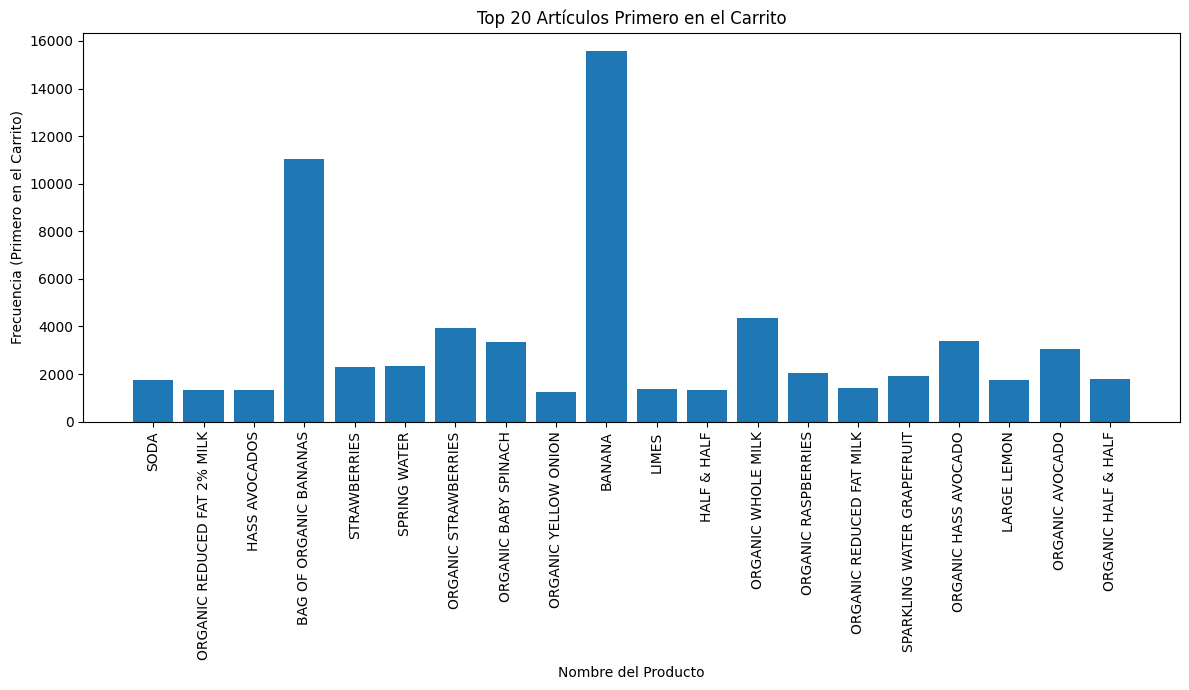

In [52]:
# Filtrar los productos que fueron añadidos primero al carrito (add_to_cart_order == 1)
first_in_cart = order_products[order_products['add_to_cart_order'] == 1]

# Contar cuántas veces cada producto fue el primero en ser añadido
first_in_cart_counts = first_in_cart['product_id'].value_counts().head(20)

# Obtener los nombres de los productos y IDs correspondientes
top_20_first_in_cart = products[products['product_id'].isin(first_in_cart_counts.index)]

# Unir con el conteo de "primero en el carrito" y ordenar
merged_top_20_first = top_20_first_in_cart.merge(first_in_cart_counts.rename('first_in_cart_count'), left_on='product_id', right_index=True)

# Graficar los 20 principales artículos primero en el carrito
plt.figure(figsize=(12, 7))
plt.bar(merged_top_20_first['product_name'], merged_top_20_first['first_in_cart_count'])
plt.xticks(rotation=90)
plt.xlabel('Nombre del Producto')
plt.ylabel('Frecuencia (Primero en el Carrito)')
plt.title('Top 20 Artículos Primero en el Carrito')
plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones

### Conclusion general del proyecto: